In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import os 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../../student_performance.csv")
print(data)

    study_hours  sleep_hours  passed
0           4.4          4.2       0
1           9.6          7.2       1
2           7.6          5.6       1
3           6.4          6.5       0
4           2.4          8.5       0
..          ...          ...     ...
95          5.4          5.7       0
96          5.7          7.6       1
97          4.8          8.5       0
98          1.2          8.4       0
99          2.0          7.9       0

[100 rows x 3 columns]


In [3]:
X = data.iloc[:, 0:2].to_numpy()
print(X[:5])
print(X.shape)
Y = data.iloc[:, 2].to_numpy()
print(Y[:5])
print(Y.shape)

[[4.4 4.2]
 [9.6 7.2]
 [7.6 5.6]
 [6.4 6.5]
 [2.4 8.5]]
(100, 2)
[0 1 1 0 0]
(100,)


Study Hours Range: 0.0 - 10.9
Sleep Hours Range: 3.0 - 9.9
[False  True  True False False] [ True False False  True  True]


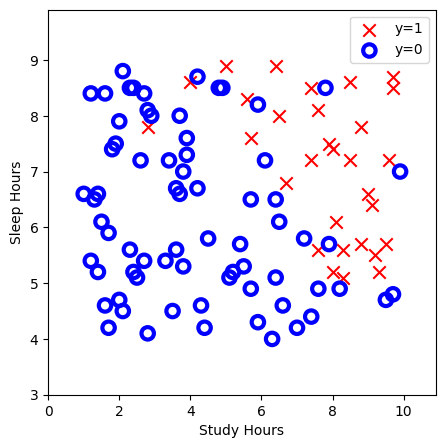

In [4]:
# Create a grid covering the feature space
study_min, study_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # Study hours
sleep_min, sleep_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # Sleep hours

print(f"Study Hours Range: {study_min} - {study_max}")
print(f"Sleep Hours Range: {sleep_min} - {sleep_max}")

fig,ax = plt.subplots(1,1,figsize=(5,5))

pos = Y == 1
neg = Y == 0
print(pos[:5], neg[:5])

ax.scatter(X[pos, 0], X[pos, 1], s=80, marker="x", color="red", label="y=1")
ax.scatter(X[neg, 0], X[neg, 1], s=80, marker="o", facecolor="none", color="blue", label='y=0', lw=3)
ax.legend()

ax.axis([study_min, study_max, sleep_min, sleep_max])
ax.set_xlabel('Study Hours')
ax.set_ylabel('Sleep Hours')
plt.show()

In [5]:
lr_model = LogisticRegression()
lr_model.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
print(lr_model.predict([[8.5, 6.6]]))
print(lr_model.predict_proba([[8.5, 6.6]])[:, 1])

[1]
[0.78171073]


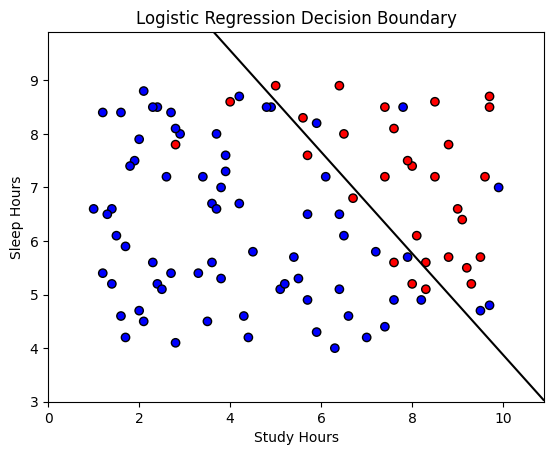

In [66]:
# Create a grid covering the feature space
study, sleep = np.meshgrid(np.linspace(study_min, study_max, 100),
                     np.linspace(sleep_min, sleep_max, 100))
# Predict probabilities for each point in the grid
grid = np.c_[study.ravel(), sleep.ravel()]
probs = lr_model.predict_proba(grid)[:, 1].reshape(study.shape)

# Plot decision boundary and data points
plt.contour(study, sleep, probs, levels=[0.5], colors='black')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr', edgecolor='k')
plt.xlabel('Study Hours')
plt.ylabel('Sleep Hours')
plt.title('Logistic Regression Decision Boundary')
plt.show()

In [68]:
# Saving Model locally
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("student_pass_prediction")
with mlflow.start_run():
    # Log model hyperparameters
    mlflow.log_param("solver", lr_model.solver)
    mlflow.log_param("max_iter", lr_model.max_iter)

    # Log Accuracy
    accuracy = lr_model.score(X, Y)
    mlflow.log_metric("accuracy", accuracy)

    # Log trained model 
    mlflow.sklearn.log_model(lr_model, artifact_path="logistic_model")

2025/11/16 23:25:27 INFO mlflow.tracking.fluent: Experiment with name 'student_pass_prediction' does not exist. Creating a new experiment.


2025/11/16 23:25:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 23:25:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run auspicious-fawn-87 at: http://localhost:5000/#/experiments/1/runs/d6b62a54ef8745f7a2de131497f53c66
🧪 View experiment at: http://localhost:5000/#/experiments/1
